<a href="https://colab.research.google.com/github/Rehman-Cg7/AIML/blob/main/Week_4_T_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Build a Proper ML Pipeline with Feature **Engineering**

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Engineered **Features**

In [5]:
# Feature 1: Family Size (Siblings/Spouse + Parents/Children + khud)
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

# Feature 2: IsAlone (kya passenger akela travel kar raha tha?)
titanic['IsAlone'] = (titanic['FamilySize'] == 1).astype(int)

titanic[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


I created two new features:

* **FamilySize:** Family size can affect survival. In a very large family, it may have been more difficult for everyone to reach the lifeboats, while a passenger traveling alone could move more quickly.
* **IsAlone:** This feature directly indicates whether a passenger was traveling alone or with family members. Sometimes, passengers traveling alone may have had different survival chances compared to those traveling with family.


# **Select Features (Separate X and y)**

In [6]:
# Missing target rows hatao (agar Survived mein koi missing ho)
titanic = titanic.dropna(subset=['Survived'])

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = titanic[features]
y = titanic['Survived']

X.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,7.2500,S,2,0
1,1,female,38.0,71.2833,C,2,0
2,3,female,26.0,7.9250,S,1,1
3,1,female,35.0,53.1000,S,2,0
4,3,male,35.0,8.0500,S,1,1


## Identify Numerical and Categorical Columns

This is one of the most important concepts in the pipeline. We identify which columns contain numerical values that need to be scaled and which columns contain categorical values that need to be encoded.

In [7]:
numerical_cols = ['Age', 'Fare', 'FamilySize']
categorical_cols = ['Pclass', 'Sex', 'Embarked']

## **Create a ColumnTransformer**

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical columns ke liye: missing values fill karo, phir scale karo
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical columns ke liye: missing values fill karo, phir encode karo
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer: har column type ko uska sahi transformer do
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Working
1. **SimpleImputer** — Automatically fills missing values. For numerical columns, it uses the **median**, while for categorical columns, it uses the **most frequent value**. Previously, we handled missing values manually using `fillna()`.

2. **StandardScaler** — Brings numerical values to a **common scale**. For example, Age may range from 0–80 while Fare may range from 0–500. Scaling makes these values easier for the model to process.

3. **OneHotEncoder** — Performs the same basic task as `pd.get_dummies()`, but in a **pipeline-friendly way**.

4. **ColumnTransformer** — Acts like a **traffic controller**. It sends numerical columns through the scaling process and categorical columns through the encoding process, ensuring each type is processed correctly.


# **Chain Preprocessing and Model into a Pipeline**

In [9]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

Now, `model_pipeline` is a **complete package**. You can provide raw, uncleaned data, and it will automatically **clean, scale, encode, and make predictions**. Everything is handled within a single object.


# **Train-Test Split and Fit the Pipeline**


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bas ye ek line — sara preprocessing + training ho jayega
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Important**: Notice that we provided raw data to X_train, including missing values and text categories. We did not clean or preprocess the data manually. The pipeline automatically handled missing values, scaling, and encoding before training the model.*italicized text*

# Evaluate and Compare with the Manual **Approach**

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_pipeline.predict(X_test)

print("Pipeline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Pipeline Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Pipeline vs. Manual Approach Comparison

**Manual approach (Task 3):** 81.01% accuracy — data cleaning, encoding, and training were performed manually in separate cells, without any feature engineering.

**Pipeline approach (Task#4):** 79.89% accuracy — all preprocessing steps were combined into a single **Pipeline** using **ColumnTransformer**, including **StandardScaler** and **OneHotEncoder**. Two new engineered features, **FamilySize** and **IsAlone**, were also added.

There is only about a **1% difference in accuracy**, which is relatively small. Both approaches show roughly similar predictive performance. However, the main advantage of the pipeline approach is **code quality and consistency**, rather than higher accuracy. All preprocessing steps are contained in a single, reusable object and are applied consistently to both training and test data, reducing the risk of data leakage. This also makes the model easier to use with new data and more suitable for **production and real-world ML systems**.

The new features, **FamilySize** and **IsAlone**, did not dramatically improve accuracy. However, this is still a valuable learning outcome: **not every new feature guarantees better model performance, and evaluating their actual impact is an important machine learning skill.**


# Save the Pipeline Using **Joblib**

In [12]:
# Baad mein load karne ka tareeqa (abhi ke liye sirf jaan lein)
# loaded_pipeline = joblib.load('titanic_pipeline.pkl')

# from google.colab import files
# files.download('titanic_pipeline.pkl')

In [13]:
import joblib

joblib.dump(model_pipeline, 'titanic_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


Using this code to loat data set
# **Thanks**



# **Ensemble Learning: Random Forest vs XGBoost**

In [14]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# Feature engineering (Pipeline task se)
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic['IsAlone'] = (titanic['FamilySize'] == 1).astype(int)

# Missing values handle karo
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

# Encoding
titanic_encoded = pd.get_dummies(titanic, columns=['Sex', 'Embarked'], drop_first=True)

features = ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone'] + \
           [col for col in titanic_encoded.columns if 'Sex_' in col or 'Embarked_' in col]

X = titanic_encoded[features]
y = titanic_encoded['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipykernel_573/2998749666.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
/tmp/ipykernel_573/2998749666.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

## **Train Random Forest**

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## **Train XGBoost**

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## **Evaluate Ensemble Models**

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

=== Random Forest ===
Accuracy: 0.8379888268156425
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       105
           1       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


=== XGBoost ===
Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       105
           1       0.79      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



### **Comparisen With Task 3 Regration Modle**

In [18]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression (Single Model) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))

=== Logistic Regression (Single Model) ===
Accuracy: 0.7988826815642458


## **Comparison Table**

In [21]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Single)', 'Random Forest (Ensemble)', 'XGBoost (Ensemble)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression (Single),0.798883
1,Random Forest (Ensemble),0.837989
2,XGBoost (Ensemble),0.826816


## **Plot Feature Importance for Both Models**

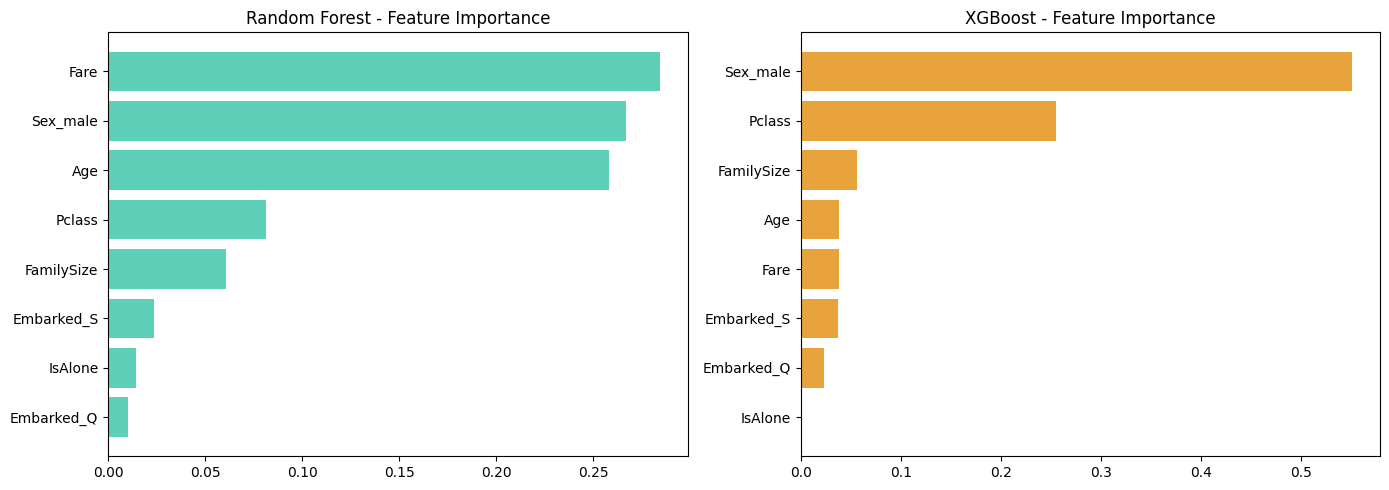

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#5FD0B8')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].invert_yaxis()

axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#E8A33D')
axes[1].set_title('XGBoost - Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# **Explanation**

## Random Forest vs. XGBoost — How Are They Different?

Random Forest uses the Bagging technique. It trains many Decision Trees independently and in parallel. Each tree sees a different random sample of the data, and the final prediction is made based on the majority vote of all the trees.

XGBoost uses the Boosting technique. It trains trees sequentially, one after another. Each new tree focuses specifically on the errors made by the previous trees and tries to improve the overall prediction.

Because of this, Random Forest is generally more stable and less prone to overfitting, while XGBoost often achieves higher accuracy when properly tuned. However, XGBoost can have a higher risk of overfitting if it is not carefully tuned.
### Key Learning
Random Forest uses bagging (parallel, independent trees + voting), while
XGBoost uses boosting (sequential trees that correct previous errors).

**Difference B/t Boosting and Bagging Technique ?**


